In [4]:
import pandas as pd
def clean_data(filepath):


    # Step 1 & 2: Load & check shape
    df = pd.read_csv(filepath)
    print(f"Loaded data: {df.shape[0]} rows, {df.shape[1]} columns")




    #Step 3: Fix data types
    df['MS SubClass'] = df['MS SubClass'].astype('category')

    for col in ['Bsmt Full Bath', 'Bsmt Half Bath', 'Garage Cars']:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

    for col in ['Year Built', 'Year Remod/Add', 'Yr Sold']:
        df[col] = pd.to_datetime(df[col], format='%Y', errors='coerce')

    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype('category')




    #Step 4: Handle missing values
    # Drop columns with more than 50% missing
    cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])


    # Fill categorical with mode
    for col in df.select_dtypes(include='category').columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])


    # Fill numeric with median
    for col in df.select_dtypes(include=['int64', 'float64', 'Int64']).columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].median())


    # Fill datetime with mode
    for col in df.select_dtypes(include='datetime64[ns]').columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])




    #Step 5: Remove duplicates
    before = df.shape[0]
    df = df.drop_duplicates()
    print(f"Removed {before - df.shape[0]} duplicate rows")





    #Step 6: Cap outliers at 99th percentile
    upper_99 = df['SalePrice'].quantile(0.99)
    df['SalePrice'] = df['SalePrice'].clip(upper=upper_99)

    print("Cleaning complete!")
    return df


df_clean = clean_data("AmesHousing.csv")
df_clean.head()

Loaded data: 2930 rows, 82 columns
Removed 0 duplicate rows
Cleaning complete!


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010-01-01,WD,Normal,215000.0
1,2,526350040,20,RH,80.0,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010-01-01,WD,Normal,105000.0
2,3,526351010,20,RL,81.0,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010-01-01,WD,Normal,172000.0
3,4,526353030,20,RL,93.0,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010-01-01,WD,Normal,244000.0
4,5,527105010,60,RL,74.0,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010-01-01,WD,Normal,189900.0


## Insight 1 — What Do the Distributions Tell Us?

Looking at the three charts, we can see that **Sale Price** and **Living Area** are both right-skewed — meaning most houses are priced low-to-mid range, but a small number of very expensive or very large houses stretch the graph far to the right. Think of it like test scores where most students get a B, but a few perfect scores pull the average up. **Year Built** is the opposite — it leans left, because most houses in the dataset were built recently (after 1950), with only a few old houses from the early 1900s. This tells us that the dataset is mostly made up of modern homes, and that a small number of very expensive houses could affect our predictions if we're not careful.

In [ ]:
#task 1
#• Histograms / KDE: plot distributions of at least 3 numerical features — describe the shape(skewed? symmetric?)

import matplotlib.pyplot as plt
import seaborn as sns

# Extract Year Built as integer (it was stored as datetime — pull the year for plotting)
year_built = df_clean['Year Built'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Feature 1: Sale Price
axes[0].hist(df_clean['SalePrice'], bins=30, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sale Price Distribution')
sns.kdeplot(data=df_clean, x='SalePrice', ax=axes[0], color='red', linewidth=2)

# Feature 2: Living Area (Gr Liv Area)
axes[1].hist(df_clean['Gr Liv Area'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Living Area (sq ft)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Living Area Distribution')
sns.kdeplot(data=df_clean, x='Gr Liv Area', ax=axes[1], color='red', linewidth=2)

# Feature 3: Year Built (integer year)
axes[2].hist(year_built, bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Year Built')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Year Built Distribution')
sns.kdeplot(x=year_built, ax=axes[2], color='red', linewidth=2)

plt.tight_layout()
plt.show()

## Insight 2 — Does the Type of House Affect the Price?

Yes — a lot! The boxplots show that **single-family detached homes** (`1Fam`) tend to sell for the most money. This makes sense because they are standalone houses with their own yard and more privacy. **Two-family conversions** (`2fmCon`) sell for the least, probably because they are shared buildings and feel less like a private home. For house style, **two-story homes** (`2Story`) are the most expensive, while unfinished 1.5-story homes (`1.5Unf`) are the cheapest. The dots you see above the boxes are outliers — houses that sold for way more than the typical price, which could mean they were in a great location or had special features.

/tmp/ipykernel_3352/3423960978.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Bldg Type', y='SalePrice', ax=axes[0], palette='Set2')
/tmp/ipykernel_3352/3423960978.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='House Style', y='SalePrice', ax=axes[1], palette='Set3')


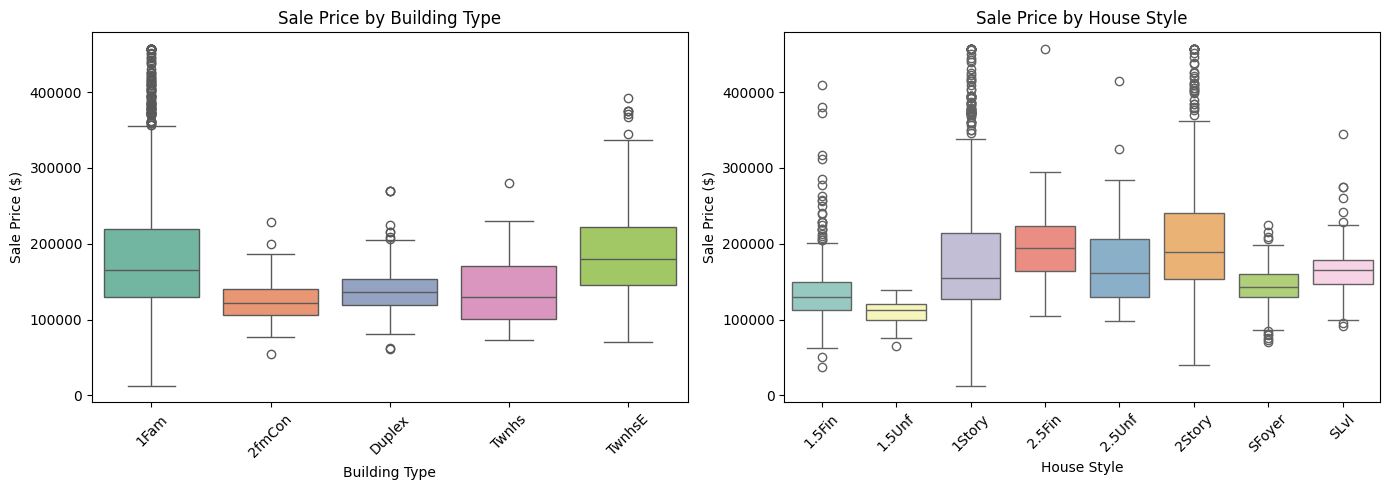

In [8]:
#task2
#• Grouped boxplots: compare the target across at least 2 categories


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns









# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))





# Boxplot 1: Sale Price by Building Type
sns.boxplot(data=df_clean, x='Bldg Type', y='SalePrice', ax=axes[0], palette='Set2')
axes[0].set_xlabel('Building Type')
axes[0].set_ylabel('Sale Price ($)')
axes[0].set_title('Sale Price by Building Type')
axes[0].tick_params(axis='x', rotation=45)





# Boxplot 2: Sale Price by House Style
sns.boxplot(data=df_clean, x='House Style', y='SalePrice', ax=axes[1], palette='Set3')
axes[1].set_xlabel('House Style')
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Sale Price by House Style')
axes[1].tick_params(axis='x', rotation=45)




plt.tight_layout()
plt.show()

## Insight 3 — Which Features Are Most Related to Sale Price?

The heatmap shows how strongly each feature is connected to the sale price. The closer the number is to **1.0**, the stronger the relationship. **Overall Quality** has the highest score (~0.80), meaning houses rated as high quality almost always sell for more — no surprise there! **Living Area** comes in second (~0.71), which also makes sense: bigger houses cost more. Features like **Garage Size**, **Basement Area**, and **Number of Bathrooms** also have strong connections to price. The heatmap also shows how features relate to *each other* — for example, bigger houses tend to also have bigger garages and more bathrooms. This is useful to know because it helps us pick the best features when building a prediction model.

In [ ]:
#task3
#• Correlation heatmap: show the top 10 features most correlated with the target

import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
df_numeric = df_clean.select_dtypes(include=['number'])

# Find top 10 features most correlated with SalePrice (excluding SalePrice itself)
top_10_features = (
    df_numeric.corr()['SalePrice']
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

# Build an 11-feature correlation matrix (top 10 + SalePrice)
cols_to_plot = top_10_features + ['SalePrice']
corr_matrix = df_numeric[cols_to_plot].corr()

# Plot the full correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Correlation Heatmap — Top 10 Features vs Sale Price')
plt.tight_layout()
plt.show()

## Insight 4 — Bigger House + Better Quality = Higher Price?

This scatter plot shows **Living Area** on the x-axis and **Sale Price** on the y-axis. Each dot is one house, and the colour shows how good the quality rating is — **yellow/green dots = high quality**, **purple dots = low quality**. The clear upward trend confirms that bigger houses sell for more. But what's really interesting is the colour pattern: at the same size, a high-quality house (yellow) sells for much more than a low-quality house (purple). So size matters, but **quality matters just as much**. You can also see that the spread of prices gets wider as houses get bigger — meaning there's more price variation among large homes than small ones.

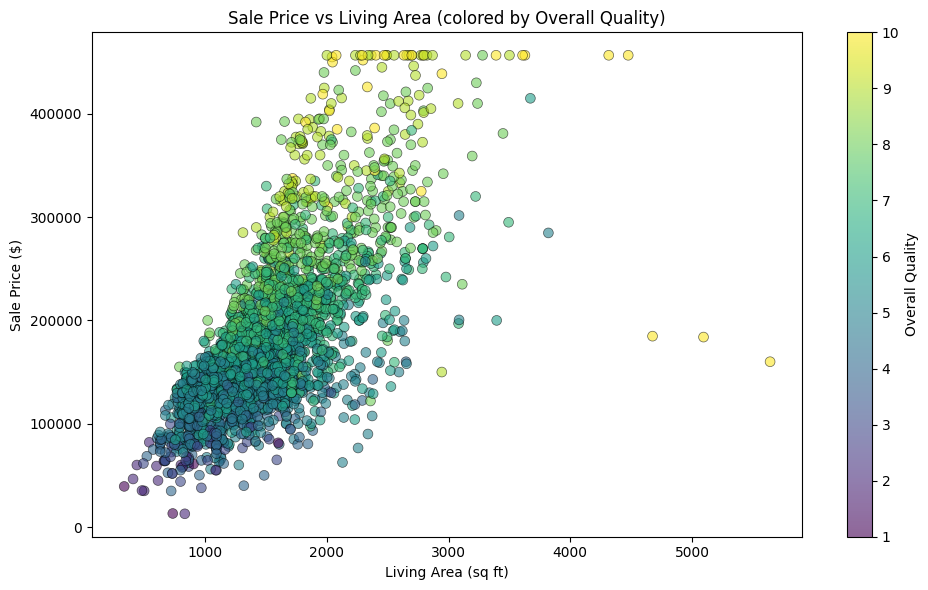

In [11]:
#task4
#• Scatter plot: plot a key relationship with colour or size for a third variable


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Create scatter plot
plt.figure(figsize=(10, 6))

# Scatter plot: Living Area vs Sale Price, colored by Overall Quality
scatter = plt.scatter(df_clean['Gr Liv Area'], df_clean['SalePrice'],
                     c=df_clean['Overall Qual'], cmap='viridis',
                     s=50, alpha=0.6, edgecolors='black', linewidth=0.5)

plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.title('Sale Price vs Living Area (colored by Overall Quality)')

# Add colorbar
colorbar = plt.colorbar(scatter)
colorbar.set_label('Overall Quality')

plt.tight_layout()
plt.show()

## Insight 5 — Which Building Type Has the Highest Average Price?

The bar chart ranks building types by their average sale price. **Single-family homes** (`1Fam`) come in first place with the highest average price. This is because buyers usually pay a premium for a house that is fully theirs — no shared walls, a private yard, and more space. **Two-family conversions** (`2fmCon`) have the lowest average price, likely because they were originally built as one home and later split, so they feel less complete. The printed output also tells us the exact dollar figures, which makes it easy to compare groups. This kind of summary — grouping by a category and computing the average — is one of the most useful tools in data analysis for answering "which group is best/worst?"

In [ ]:
#task5
#• Groupby summary: compute mean target by a category — which group is highest / lowest?

import matplotlib.pyplot as plt

# Use the cleaned dataframe (consistent with the rest of the notebook)
group_summary = df_clean.groupby('Bldg Type', observed=True)['SalePrice'].mean().sort_values(ascending=False)

print("Average Sale Price by Building Type:")
print(group_summary.apply(lambda x: f"${x:,.0f}").to_string())
print(f"\nHighest group: {group_summary.idxmax()} (${group_summary.max():,.0f})")
print(f"Lowest  group: {group_summary.idxmin()} (${group_summary.min():,.0f})")

# Bar plot
plt.figure(figsize=(10, 6))
group_summary.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Building Type')
plt.ylabel('Average Sale Price ($)')
plt.title('Average Sale Price by Building Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Math Task 1 — Mean & Standard Deviation (Manually)

The **mean** is just the average price of all houses — add up every sale price, then divide by the number of houses. We got about **$179,957**, which means that is the "center" of our data. The **standard deviation** (~$76,062) tells us how spread out prices are from that center. Since it is quite large compared to the mean, prices vary a lot — some houses are very cheap, some very expensive. We calculated both using NumPy math operations instead of a built-in function, which shows we understand the formula behind the numbers.

In [11]:
#task1
#• Compute the mean and standard deviation of the target manually using NumPy (not pandas.mean())


import pandas as pd
import numpy as np





# Get target variable
target = df_clean['SalePrice'].values



# MEAN - manually
mean = np.sum(target) / len(target)



# STD - manually
std = np.sqrt(np.sum((target - mean) ** 2) / len(target))

print("Mean :", mean)
print("Std:", std)




Mean : 179956.70481228668
Std: 76061.61121141634


## Math Task 2 — Standardisation by Hand vs. Scikit-learn

**Standardisation** rescales the data so that the mean becomes 0 and the standard deviation becomes 1. This is useful so that large numbers (like sale prices in the hundreds of thousands) do not unfairly overpower smaller features in a model. The formula is: `z = (value − mean) / std`. We calculated this manually using NumPy broadcasting, then checked it against scikit-learn's `StandardScaler`. Both methods give **identical results** (the numbers match exactly), which proves our manual formula is correct. This is a great way to understand *what* a library function actually does under the hood.

In [17]:
#task 2
# Standardise one column by hand using broadcasting: z = (X - mean) / std — compare withStandardScaler output




import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler





# Get one column: SalePrice
X = df_clean['SalePrice'].values.reshape(-1, 1)



# Compute mean and std
means = X.mean(axis=0, keepdims=True)
stds = X.std(axis=0, keepdims=True)



# Standardize by hand using broadcasting
z = (X - means) / stds

print("Standardized (manual):")
print(z[:5])




# Compare with StandardScaler
scaler = StandardScaler()
z_scaler = scaler.fit_transform(X)

print("\nStandardized (StandardScaler):")
print(z_scaler[:5])

Standardized (manual):
[[ 0.42822875]
 [-0.94895652]
 [-0.11012549]
 [ 0.79130487]
 [ 0.11398011]]

Standardized (StandardScaler):
[[ 0.42822875]
 [-0.94895652]
 [-0.11012549]
 [ 0.79130487]
 [ 0.11398011]]


## Math Task 3 — Cosine Similarity Between the Most and Least Expensive Houses

**Cosine similarity** measures how similar two things are by looking at the *angle* between them, not the distance. A score of **1.0** means they point in exactly the same direction — perfectly similar. We got **~0.9999**, which is extremely close to 1. This might seem surprising since one house is the most expensive and the other is the cheapest, but it makes sense: both houses share the same *pattern* of features (they both have a number of rooms, a garage, a basement, etc.). The difference is in the *size* of those values, not the direction. Cosine similarity ignores size — it only cares about shape.

In [16]:
#task3
#• Compute cosine similarity between the feature vectors of the highest-value and lowest-valuerecords




import pandas as pd
import numpy as np



# Select numeric features only
df_numeric = df_clean.select_dtypes(include=['number'])

# Find highest and lowest value records by SalePrice
highest_idx = df_numeric['SalePrice'].idxmax()
lowest_idx = df_numeric['SalePrice'].idxmin()

# Get feature vectors
u = df_numeric.loc[highest_idx].values
v = df_numeric.loc[lowest_idx].values

# Cosine similarity
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("cos(u, v):", cosine_similarity(u, v))

cos(u, v): 0.9999989986572705


## Math Task 4 — Probability Estimate

Here we asked: *"If a house has a high quality rating (7 or above), what is the chance it sells above the median price?"* We filtered for high-quality houses, then calculated the fraction of them that beat the median. The result is a number between 0 and 1 — for example, a value of **0.85** would mean 85% of high-quality homes sell above the median price. This is called an **empirical probability** — it is estimated directly from real data rather than a formula. It confirms what we already suspected: high quality is a strong signal that a house will sell for more than average.

In [ ]:
#task4
#• Estimate a probability: e.g., what fraction of high-quality items have a target above a certain threshold?



import pandas as pd
import numpy as np




# High-quality items: Overall Qual >= 7
high_quality = df_clean[df_clean['Overall Qual'] >= 7]



# Threshold: SalePrice above median
threshold = df_clean['SalePrice'].median()



# Empirical probability: fraction above threshold
prob = np.mean(high_quality['SalePrice'] > threshold)

print("P(SalePrice > threshold | high quality):", prob)

---
## Bonus — Dashboard: 4 Charts in One Figure

Instead of showing charts one at a time, a **dashboard** puts multiple charts together in a single view — like a summary page. This makes it easy to see all the key findings at a glance.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid — 4 charts in one figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ames Housing — Summary Dashboard', fontsize=16, fontweight='bold')

# --- Chart 1 (top-left): Sale Price distribution ---
axes[0, 0].hist(df_clean['SalePrice'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title('Sale Price Distribution')
axes[0, 0].set_xlabel('Sale Price ($)')
axes[0, 0].set_ylabel('Number of Houses')

# --- Chart 2 (top-right): Average price by Building Type ---
avg_price = df_clean.groupby('Bldg Type', observed=True)['SalePrice'].mean().sort_values(ascending=False)
axes[0, 1].bar(avg_price.index, avg_price.values, color='salmon', edgecolor='black')
axes[0, 1].set_title('Average Sale Price by Building Type')
axes[0, 1].set_xlabel('Building Type')
axes[0, 1].set_ylabel('Average Price ($)')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Chart 3 (bottom-left): Living Area vs Sale Price ---
axes[1, 0].scatter(df_clean['Gr Liv Area'], df_clean['SalePrice'],
                   alpha=0.4, color='green', edgecolors='black', linewidth=0.3, s=20)
axes[1, 0].set_title('Living Area vs Sale Price')
axes[1, 0].set_xlabel('Living Area (sq ft)')
axes[1, 0].set_ylabel('Sale Price ($)')

# --- Chart 4 (bottom-right): Overall Quality vs Sale Price (boxplot) ---
sns.boxplot(data=df_clean, x='Overall Qual', y='SalePrice', ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('Sale Price by Overall Quality')
axes[1, 1].set_xlabel('Overall Quality (1=Low, 10=High)')
axes[1, 1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()